In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#  <font color=blue>Histogramas y Ecualización de Imágenes</font>


Este notebook tiene como objetivo proporcionar las bases necesarias para trabajar con histogramas y ecualización en imágenes utilizando la biblioteca OpenCV con Python.

Aprenderás a calcular histogramas, interpretar su significado y aplicar técnicas de ecualización para mejorar el contraste de una imagen.

In [2]:
import cv2
import matplotlib.pyplot as plt

## <font color="#F20C60">¿Qué es un histograma de imagen?</font>

Un histograma es una representación gráfica de la distribución de los niveles de intensidad en una imagen. Muestra cuántos píxeles tienen cada nivel de gris en una imagen en escala de grises o la distribución de los colores en una imagen a color.

Para calcular el histograma de una imagen en OpenCV, utilizamos la función `cv2.calcHist()`. Puedes acceder a la documentacion [aqui](https://docs.opencv.org/4.x/d1/db7/tutorial_py_histogram_begins.html#autotoc_md1384).

### <font color=green> Sintaxis de la función </font>

``` python
hist = cv2.calcHist(img, channels, mask, histSize, ranges[, hist[, acumulado]])
```

- `hist`: nos da el resultado obtenido del cálculo del histograma.
- `img`: es la imagen fuente de tipo uint8 o float32. Debe proporcionarse entre corchetes, es decir, `[img]`
- `channels`: también se da entre corchetes. Es el índice del canal para el que calculamos el histograma. Por ejemplo, si la entrada es una imagen en escala de grises, su valor es `[0]`. Para una imagen en color, puede pasar `[0]`, `[1]` o `[2]` para calcular el histograma del canal azul, verde o rojo respectivamente.
- `mask`: imagen de máscara. Para encontrar el histograma de la imagen completa, se indica como `None`. Pero si desea encontrar el histograma de una región particular de la imagen, debe crear una imagen de máscara para eso y asignarle el valor de máscara. Por ahora no se utilizara ninguna.
- `histSize`: representa el recuento de BIN. Debe indicarse entre corchetes. Para la escala completa, pasamos `[256]`.
- `ranges`: este es nuestro RANGO. Normalmente es [0,256].

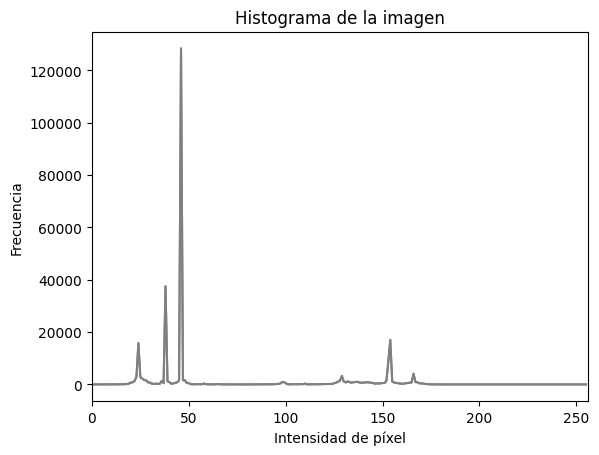

In [14]:
img = cv2.imread( './data/Escenario1.jpg' , cv2.IMREAD_GRAYSCALE)
hist = cv2.calcHist([img], [0], None, [256], [0,256])

plt.plot(hist, color='gray')
plt.title('Histograma de la imagen')
plt.xlabel('Intensidad de píxel')
plt.ylabel('Frecuencia')
plt.plot(hist, color='gray')
plt.xlim([0,256])

plt.show()

#### <font color=purple>NOTA</font>

Recuerda que para el cálculo de histogramas para imágenes a color es necesario separar cada uno de los canales para poder obtener el histograma de cada uno de los canales.


## <font color="#F20C60">Ecualización de histograma</font>

La ecualización del histograma es una técnica que mejora el contraste de una imagen ajustando su distribución de intensidad de manera más uniforme. En OpenCV, podemos aplicar esta técnica con la función `cv2.equalizeHist()`. Puedes acceder a la documentacion [aqui](https://docs.opencv.org/4.x/d5/daf/tutorial_py_histogram_equalization.html).

#### <font color = green>Sintaxis de la Función</font>

```Python
eqz = cv2.equalizeHist(src)
```

- `src`: Imagen de entrada en escala de grises.
- `eqz`: Devuelve una nueva imagen con el histograma ecualizado.

#### <font color=purple>NOTA</font>
Para poder mostrar el histograma de la ecualización es necesario volver a calcular el histograma pero ahora del resultado obtenido de la ecualización.

## <font color="#F20C60"> CLAHE (ecualización de histograma adaptativa limitada por contraste)</font>

La primera ecualización de histograma que acabamos de ver tiene en cuenta el contraste global de la imagen. En muchos casos, no es una buena idea.

Para resolver este problema, se utiliza la ecualización de histograma adaptativa . En este caso, la imagen se divide en pequeños bloques llamados "mosaicos" (el tamaño predeterminado de los mosaicos es 8x8 en OpenCV). Luego, cada uno de estos bloques se ecualiza con histograma como de costumbre. Por lo tanto, en un área pequeña, el histograma se limitaría a una región pequeña (a menos que haya ruido). Si hay ruido, se amplificará. Para evitarlo, se aplica una limitación de contraste . Si algún contenedor del histograma está por encima del límite de contraste especificado (por defecto, 40 en OpenCV), esos píxeles se recortan y se distribuyen uniformemente a otros contenedores antes de aplicar la ecualización del histograma. Después de la ecualización, para eliminar los artefactos en los bordes de los mosaicos, se aplica una interpolación bilineal.

### <font color =green>Sintaxis de la Función</font>

```python
clahe = cv2.createCLAHE (clipLimit, tileGridSize)
cl1 = clahe.apply(img)
```

- **`clahe`** - el resultado del calculo.

- **`clipLimit`** : Umbral para limitación de contraste.

- **`tileGridSize`** : Tamaño de la cuadrícula para la ecualización del histograma. La imagen de entrada se dividirá en mosaicos rectangulares de igual tamaño. tileGridSize define la cantidad de mosaicos en la fila y la columna. Por defecto se usa `(8,8)`

Una vez que se realiza el cálculo es necesario aplicarlo a la imagen, utilizando el siguiente código:

```python
cl1 = clahe.apply(img)
```

- **`cl1`** - es la imagen con el ecualizado CLAHE.

- **`img`** : imagen a la cual se le aplicara el ecualizado CLAHE.


## <font color="#F20C60"> Graficando múltiples canales en una grafica</font>

En algunas ocasiones es necesario ver todos los canales en la misma gráfica y no por separado para poder realizar comparaciones y tomar la mejor decisión a la hora de realizar mejoras en la imagen.

Puedes realizarlo a partir de un ciclo `for` para facilitar el proceso.

### <font color =green>Sintaxis de la Función</font>

```python
for i, (canal, color) in enumerate(zip(canales, colores)):
    hist = cv2.calcHist([imagen], [i], None, [256], [0, 256])
    plt.plot(hist, color=color, label=f'Canal {canal}')
```

- **`enumerate`** : agrega un índice a cada elemento de un iterable.

- **`zip`** :  es una función en Python que combina múltiples iterables (como listas o tuplas) en pares o grupos.
- **`canales`** : son los canales de la imagen para poner el nombre en la legenda de la grafica.

- **`colores`** :  son los colores de la imagen para poner a la grafica.

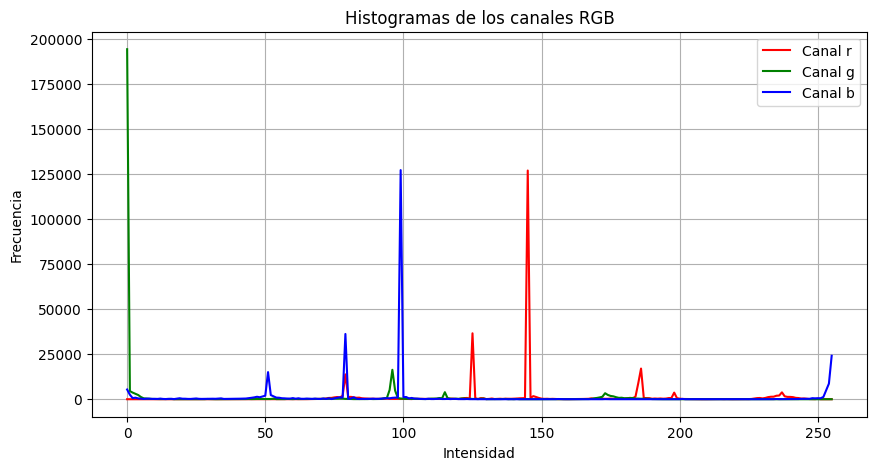

In [26]:
imagen = cv2.imread('/content/drive/MyDrive/ColabNotebooks/Clase_TI/Parcial1/1_4_Histogramas_Ecualizado./data/Escenario1.jpg')
imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

canales = ('r', 'g', 'b')
colores = ('red', 'green', 'blue')

plt.figure(figsize=(10, 5))

for i, (canal, color) in enumerate(zip(canales, colores)):
    hist = cv2.calcHist([imagen], [i], None, [256], [0, 256])
    plt.plot(hist, color=color, label=f'Canal {canal}')

plt.title('Histogramas de los canales RGB')
plt.xlabel('Intensidad')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid()

plt.show()

#### <font color=purple>NOTA</font>
Si utilizas la función `cv2.split()` para separar los colores no es necesario utilizar el `enumerate` ni el iterador `i`, por tanto en `cv2.calcHist()`, el valor de `i` seria `0`.